# Bandits — ε-greedy, UCB, Thompson Sampling

Clase 2. Tres políticas para el problema de k-armed bandits, sobre los mismos arms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## Los arms (las pdfs de reward)

In [2]:
k = 5
q_star = np.array([1.0, 1.5, 2.0, 1.2, 0.5])  # media real de cada brazo
reward_std = 1.0  # sigma del reward, igual para todos


def pull(arm):
    """Reward de tirar `arm`: ~ N(q_star[arm], reward_std)."""
    return rng.normal(q_star[arm], reward_std)

## El agente (la policy): ε-greedy

In [3]:
epsilon = 0.1
Q = np.zeros(k)  # estimación del agente para cada brazo
N = np.zeros(k)  # cuántas veces probó cada brazo


def choose_action():
    if rng.random() < epsilon:
        return rng.integers(k)  # explorar
    return np.argmax(Q)         # explotar  ### ojo que no es truly random!

## Loop: interacción Agente ↔ Arms

In [4]:
n_steps = 1000
rewards = np.zeros(n_steps)

for t in range(n_steps):
    a = choose_action()
    r = pull(a)
    N[a] += 1
    Q[a] += (r - Q[a]) / N[a]  # actualización sample-average
    rewards[t] = r

## Evaluar cómo salió

q* real:           [1.  1.5 2.  1.2 0.5]
Q estimado:         [1.03 1.23 1.94 1.24 0.19]
mejor brazo real:   2
mejor según agente: 2


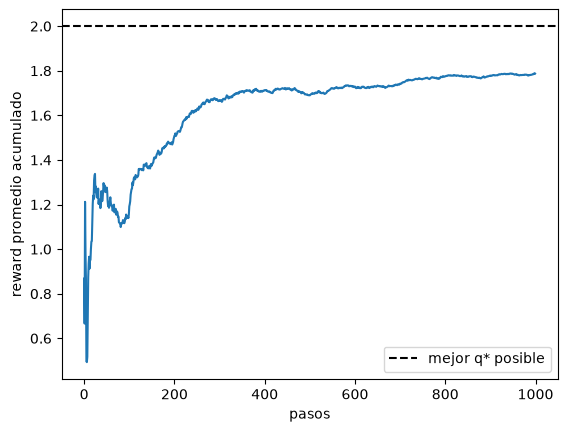

In [5]:
print("q* real:          ", np.round(q_star, 2))
print("Q estimado:        ", np.round(Q, 2))
print("mejor brazo real:  ", np.argmax(q_star))
print("mejor según agente:", np.argmax(Q))

plt.plot(np.cumsum(rewards) / np.arange(1, n_steps + 1))
plt.axhline(q_star.max(), color="k", ls="--", label="mejor q* posible")
plt.xlabel("pasos")
plt.ylabel("reward promedio acumulado")
plt.legend()
plt.show()

## Juntar estadística — una sola corrida depende de la semilla

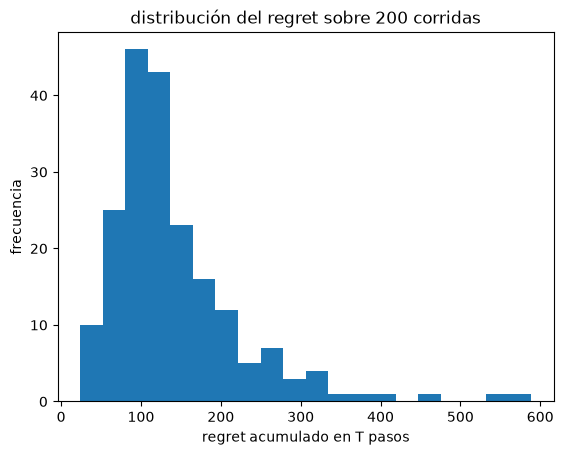

In [6]:
n_runs = 200
regret_total = []

for _ in range(n_runs):
    Q = np.zeros(k)
    N = np.zeros(k)
    total_reward = 0.0
    for t in range(n_steps):
        a = rng.integers(k) if rng.random() < epsilon else np.argmax(Q)
        r = rng.normal(q_star[a], reward_std)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        total_reward += r
    regret_total.append(n_steps * q_star.max() - total_reward)

plt.hist(regret_total, bins=20)
plt.xlabel("regret acumulado en T pasos")
plt.ylabel("frecuencia")
plt.title(f"distribución del regret sobre {n_runs} corridas")
plt.show()

## Otra policy para los mismos arms: UCB

In [7]:
c = 2.0
Q_ucb = np.zeros(k)
N_ucb = np.zeros(k)


def choose_action_ucb(t):
    if 0 in N_ucb:
        return np.argmin(N_ucb)  # probar cada brazo 1 vez (evita log(t)/0)
    return np.argmax(Q_ucb + c * np.sqrt(np.log(t) / N_ucb))

## Loop UCB (mismos arms gaussianos de arriba)

In [8]:
for t in range(1, n_steps + 1):
    a = choose_action_ucb(t)
    r = pull(a)
    N_ucb[a] += 1
    Q_ucb[a] += (r - Q_ucb[a]) / N_ucb[a]

print("Q estimado (UCB):", np.round(Q_ucb, 2))
print("mejor según UCB: ", np.argmax(Q_ucb))
print("mejor real:      ", np.argmax(q_star))

Q estimado (UCB): [1.08 1.59 1.99 0.94 0.47]
mejor según UCB:  2
mejor real:       2


## Thompson Sampling (Bernoulli)

In [9]:
p_star = np.array([0.5, 0.55, 0.6, 0.52, 0.4])  # prob. real de éxito
alpha = np.ones(k)  # prior Beta(1,1) por brazo
beta = np.ones(k)


def choose_action_thompson():
    theta_sample = rng.beta(alpha, beta)  # sample del posterior
    return np.argmax(theta_sample)

## Loop Thompson

In [10]:
for _ in range(n_steps):
    a = choose_action_thompson()
    r = rng.binomial(1, p_star[a])
    if r:
        alpha[a] += 1
    else:
        beta[a] += 1

media_posterior = alpha / (alpha + beta)
print("p* real:         ", np.round(p_star, 2))
print("media posterior: ", np.round(media_posterior, 2))
print("mejor Thompson:  ", np.argmax(media_posterior))
print("mejor real:      ", np.argmax(p_star))

p* real:          [0.5  0.55 0.6  0.52 0.4 ]
media posterior:  [0.54 0.57 0.6  0.38 0.38]
mejor Thompson:   2
mejor real:       2
